In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Python libraries loaded successfully!")

Python libraries loaded successfully!


In [69]:
from google.colab import files

uploaded = files.upload()

Saving sales_data.csv to sales_data (10).csv


In [70]:
df = pd.read_csv("sales_data.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 500
Columns: 9


,Order_ID,Order_Date,Customer,Product,Category,Region,Quantity,Sales,Profit
0,ORD00001,2025-05-21,Customer_014,Monitor,Electronics,North,1,246.73,39.61
1,ORD00002,2025-01-17,Customer_065,Webcam,Electronics,North,7,570.75,109.74
2,ORD00003,2025-11-29,Customer_058,Tablet,Electronics,East,4,1747.65,221.71
3,ORD00004,2025-12-24,Customer_028,Laptop,Electronics,East,3,2510.53,374.92
4,ORD00005,2025-07-14,Customer_078,Monitor,Electronics,East,2,478.06,95.02


In [71]:
# Check missing values and duplicate records

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Order_ID      0
Order_Date    0
Customer      0
Product       0
Category      0
Region        0
Quantity      0
Sales         0
Profit        0
dtype: int64

Duplicate Rows: 0


In [72]:
# Check data types and basic statistics

print("Data Types:")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Data Types:
Order_ID       object
Order_Date     object
Customer       object
Product        object
Category       object
Region         object
Quantity        int64
Sales         float64
Profit        float64
dtype: object

Basic Statistics:


,Quantity,Sales,Profit
count,500.000000,500.00000,500.000000
mean,4.350000,1070.77250,167.149900
std,2.264012,1201.36346,181.330041
min,1.000000,27.71000,6.260000
25%,2.000000,257.41500,49.310000
50%,4.000000,611.65500,103.225000
75%,6.000000,1512.83500,221.695000
max,8.000000,6832.96000,1165.820000


In [73]:
# Overall Sales and Profit

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_quantity = df["Quantity"].sum()
profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 535386.25
Total Profit: 83574.95
Total Orders: 500
Total Quantity Sold: 2175
Profit Margin: 15.61 %


In [74]:
# Category-wise Sales and Profit

category_analysis = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values(
    by="Sales", ascending=False
)

category_analysis

,Sales,Profit
Category,,
Electronics,340483.89,52311.61
Furniture,102420.72,15773.65
Office,59436.87,8399.67
Accessories,33044.77,7090.02


In [75]:
# Region-wise Sales and Profit

region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values(
    by="Sales", ascending=False
)

region_analysis

,Sales,Profit
Region,,
East,155949.53,24198.85
West,132016.27,20647.80
North,129175.39,20231.73
South,118245.06,18496.57


In [76]:
# Monthly Sales Trend

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Sales"].sum()

monthly_sales

,Sales
Order_Date,
2025-01,38577.79
2025-02,48093.48
2025-03,50546.48
2025-04,38997.23
2025-05,46540.83
2025-06,35815.13
2025-07,51107.82
2025-08,53304.48
2025-09,40527.80


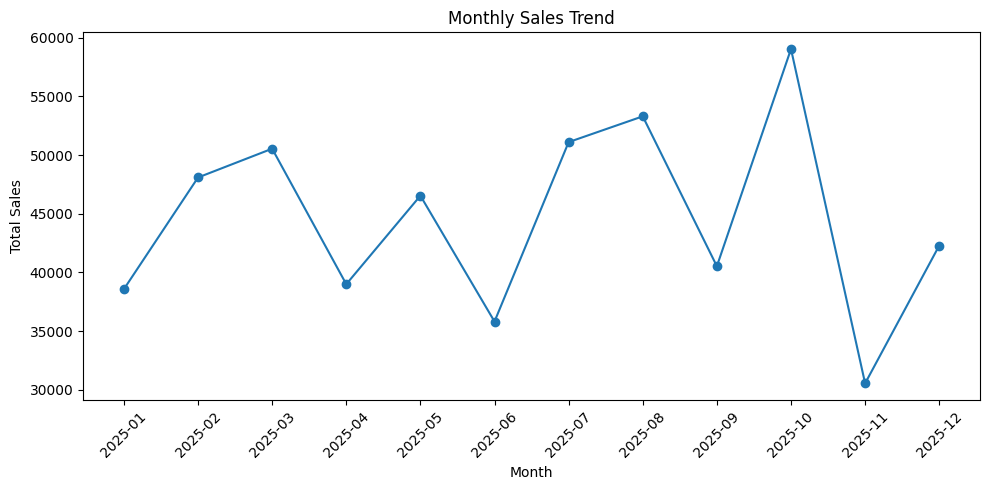

In [77]:
# Monthly Sales Trend Chart

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
# Top 10 Products by Sales

top_products = df.groupby("Product")[["Sales", "Profit"]].sum().sort_values(
    by="Sales", ascending=False
).head(10)

top_products

,Sales,Profit
Product,,
Laptop,143507.56,22512.83
Tablet,119497.72,15328.46
Desk,71252.90,10444.19
Monitor,59734.87,10758.51
Printer,59436.87,8399.67
Desk Chair,31167.82,5329.46
Webcam,17743.74,3711.81
Keyboard,14094.97,3069.52
Headphones,13293.56,2671.64


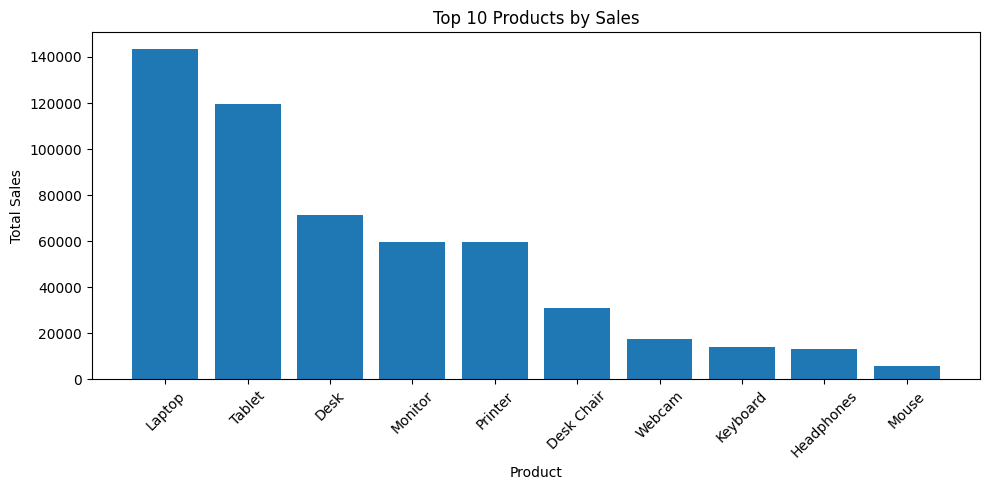

In [79]:
# Top 10 Products by Sales Chart

plt.figure(figsize=(10, 5))
plt.bar(top_products.index, top_products["Sales"])
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()